## Logistic Regression

In [4]:
# Approach 3: Logistic Regression
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import sklearn.model_selection as ms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("cleaned_dataset.csv")

Encode categorical columns that are not already binary

In [5]:
# create label encoders for categorical variables
categorical_cols = ["type_of_breast_surgery", "cancer_type", "cancer_type_detailed","cellularity", "pam50_+_claudin-low_subtype", "er_status_measured_by_ihc","er_status", "her2_status_measured_by_snp6", "her2_status",
"inferred_menopausal_state", "integrative_cluster", "primary_tumor_laterality","pr_status", "3-gene_classifier_subtype", "death_from_cancer"]

encoders = {}

# encode each column
for col in categorical_cols:
    le = LabelEncoder()
    # save the original (true) labels
    data[f"true_{col}"] = data[col]
    data[col] = le.fit_transform(data[col])
    encoders[col] = le


Split data into x and y 

In [7]:
data.dropna(inplace=True)

# separate data into X and Y
true_cols = [col for col in data.columns if col.startswith("true_")]
X = data.drop(columns=["overall_survival", "death_from_cancer", "event_observed"] + true_cols)
y = data["overall_survival"]

X = X.drop(columns=["cluster"], errors="ignore")

# split data into training and testing for X and Y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Fit model and predict

In [8]:
# test penalties
pen_val=['l1','l2']
C_val=2. ** np.arange(-5, 10, step=2)
grid_s=[{'C': C_val, 'penalty': pen_val}]
model=LogisticRegression(max_iter=1000,solver='liblinear')

# use GridSearchCV for 10 fold cross validation and fit the model using training data
cv_logr=GridSearchCV(estimator=model, param_grid=grid_s, cv=ms.KFold(n_splits=10))
cv_logr.fit(X_train, y_train)

# get the best C value and penalty
best_c=cv_logr.best_params_['C']
best_penalty=cv_logr.best_params_['penalty']
print("The best parameters are: cost={0} and penalty={1}".format(best_c, best_penalty))

# fit logistic regression model using the best parameters
model=LogisticRegression(C=best_c,penalty=best_penalty,solver='liblinear')
model.fit(X_train, y_train)

# predict using testing data
predict=model.predict(X_test)
y_proba=model.predict_proba(X_test)

print(f"Accuracy:",model.score(X_test, y_test))

The best parameters are: cost=0.125 and penalty=l1
Accuracy: 0.7603686635944701


Calculate probablity and auc 

In [9]:
from sklearn import metrics
from sklearn.metrics import classification_report

# probability for each class 0,1
y_pred_proba=model.predict_proba(X_test)[:,1]

# calculate auc
auc=metrics.roc_auc_score(y_test, y_pred_proba)

print(classification_report(y_test, predict))
print("AUC:",auc)

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       121
           1       0.74      0.70      0.72        96

    accuracy                           0.76       217
   macro avg       0.76      0.75      0.76       217
weighted avg       0.76      0.76      0.76       217

AUC: 0.8336776859504131


Create confusion matrix

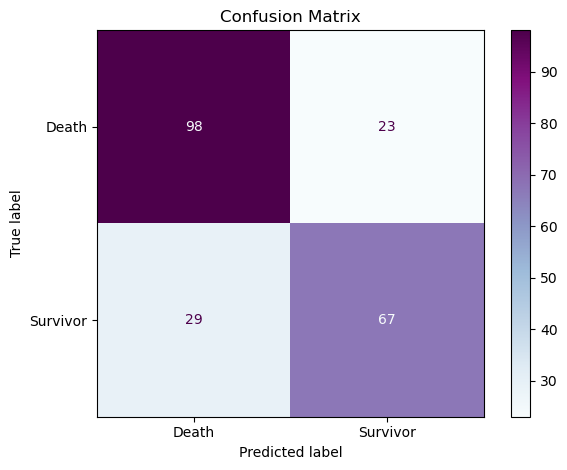

In [10]:
# create confusion matrix figure
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

matrix=confusion_matrix(y_test, predict)
fig=ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["Death", "Survivor"])
fig.plot(cmap="BuPu")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Create Roc curve

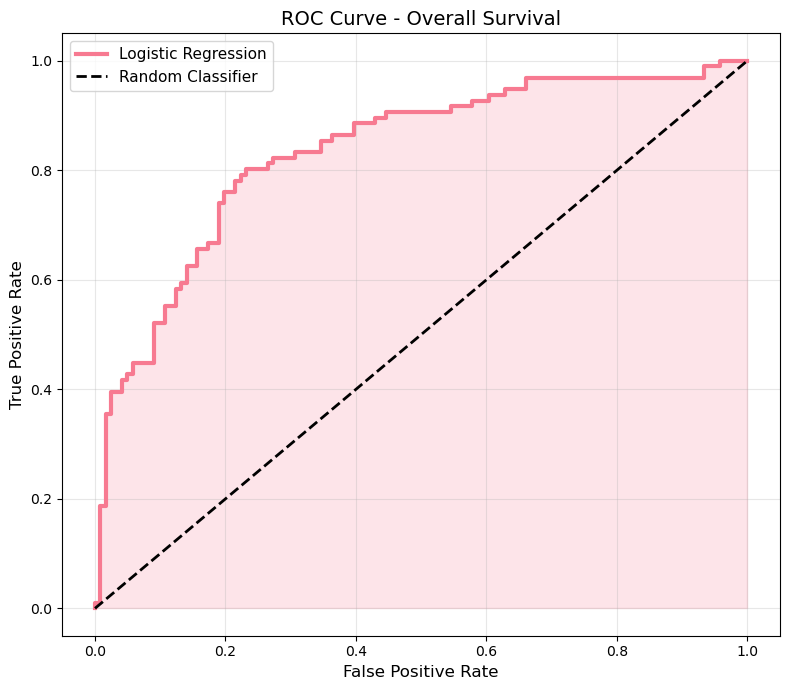

AUC 0.8336776859504131


In [11]:
# get fpr and tpr
fpr, tpr, thresholds=roc_curve(y_test, y_pred_proba)

# create figure for ROC curve
fig, ax=plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, linewidth=3, label=f"Logistic Regression", color="#f77a91")
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.2, color="#f77a91")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - Overall Survival", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print auc score
print("AUC", roc_auc_score(y_test, y_pred_proba))

Calculate feature importance and create figure

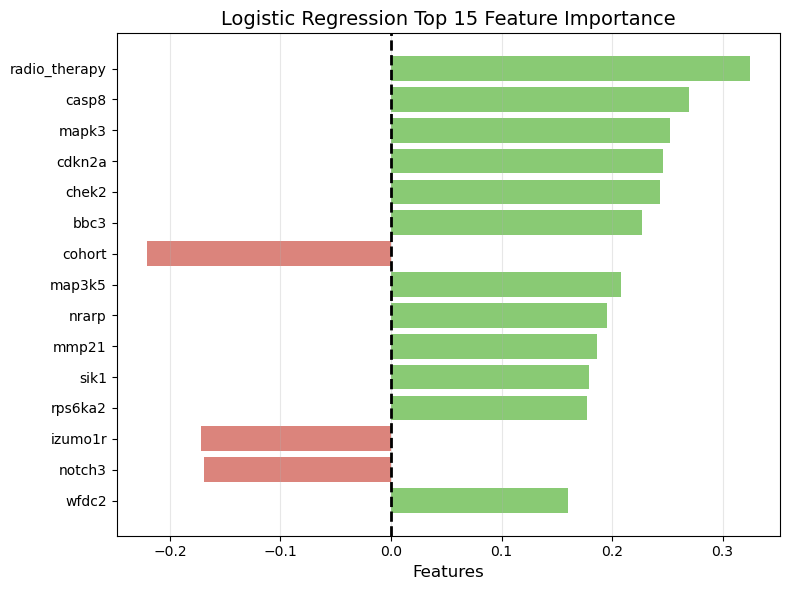

In [12]:
# create dataframe of coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]})

# sort by absolute coefficient size
coef_df["Abs"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs", ascending=False)

# keep top 15
top_coef = coef_df.head(15)

# create figure
fig, ax=plt.subplots(figsize=(8, 6))

# red for negative coefficients and green for positive
colors=["#cd5045" if c < 0 else "#57b439" for c in top_coef["Coefficient"]]
ax.barh(top_coef["Feature"], top_coef["Coefficient"], color=colors, alpha=0.7)
ax.set_xlabel("Coefficients", fontsize=12)
ax.set_xlabel("Features", fontsize=12)
ax.set_title("Logistic Regression Top 15 Feature Importance", fontsize=14)
ax.axvline(x=0, color="black", linestyle="--", linewidth=2)
ax.grid(True, alpha=0.3, axis="x")
ax.invert_yaxis()
plt.tight_layout()
plt.show()